In [1]:
import Waveform_Simulation as ws
import numpy as np
import matplotlib.pyplot as plt
import math

OUTPUT_DIR = "Simulated_Waveforms"

PD1_coords = np.array([1.2, 2.3, 3.1])
PD2_coords = np.array([2.9, 6.3, 5.4])
PD3_coords = np.array([4.5, 7.8, 6.2])
PD4_coords = np.array([6.1, 1.7, 3.5])
PD5_coords = np.array([7.8, 1.2, 4.9])
PD6_coords = np.array([9.2, 3.5, 2.8])

S4_coords = np.array([1,9,1.8])
S3_coords = np.array([1,7,1.4])
S2_coords = np.array([1,5,1.8])
S1_coords = np.array([1,3,1.4])

c = 3e8

PD1_TDOA12 = np.absolute(np.linalg.norm(PD1_coords - S2_coords)-np.linalg.norm(PD1_coords - S1_coords)) / c
PD1_TDOA13 = np.absolute(np.linalg.norm(PD1_coords - S3_coords)-np.linalg.norm(PD1_coords - S1_coords)) / c
PD1_TDOA14 = np.absolute(np.linalg.norm(PD1_coords - S4_coords)-np.linalg.norm(PD1_coords - S1_coords)) / c

PD2_TDOA12 = np.absolute(np.linalg.norm(PD2_coords - S2_coords)-np.linalg.norm(PD2_coords - S1_coords)) / c
PD2_TDOA13 = np.absolute(np.linalg.norm(PD2_coords - S3_coords)-np.linalg.norm(PD2_coords - S1_coords)) / c
PD2_TDOA14 = np.absolute(np.linalg.norm(PD2_coords - S4_coords)-np.linalg.norm(PD2_coords - S1_coords)) / c

PD3_TDOA12 = np.absolute(np.linalg.norm(PD3_coords - S2_coords)-np.linalg.norm(PD3_coords - S1_coords)) / c
PD3_TDOA13 = np.absolute(np.linalg.norm(PD3_coords - S3_coords)-np.linalg.norm(PD3_coords - S1_coords)) / c
PD3_TDOA14 = np.absolute(np.linalg.norm(PD3_coords - S4_coords)-np.linalg.norm(PD3_coords - S1_coords)) / c

PD4_TDOA12 = np.absolute(np.linalg.norm(PD4_coords - S2_coords)-np.linalg.norm(PD4_coords - S1_coords)) / c
PD4_TDOA13 = np.absolute(np.linalg.norm(PD4_coords - S3_coords)-np.linalg.norm(PD4_coords - S1_coords)) / c
PD4_TDOA14 = np.absolute(np.linalg.norm(PD4_coords - S4_coords)-np.linalg.norm(PD4_coords - S1_coords)) / c

PD5_TDOA12 = np.absolute(np.linalg.norm(PD5_coords - S2_coords)-np.linalg.norm(PD5_coords - S1_coords)) / c
PD5_TDOA13 = np.absolute(np.linalg.norm(PD5_coords - S3_coords)-np.linalg.norm(PD5_coords - S1_coords)) / c
PD5_TDOA14 = np.absolute(np.linalg.norm(PD5_coords - S4_coords)-np.linalg.norm(PD5_coords - S1_coords)) / c

PD6_TDOA12 = np.absolute(np.linalg.norm(PD6_coords - S2_coords)-np.linalg.norm(PD6_coords - S1_coords)) / c
PD6_TDOA13 = np.absolute(np.linalg.norm(PD6_coords - S3_coords)-np.linalg.norm(PD6_coords - S1_coords)) / c
PD6_TDOA14 = np.absolute(np.linalg.norm(PD6_coords - S4_coords)-np.linalg.norm(PD6_coords - S1_coords)) / c

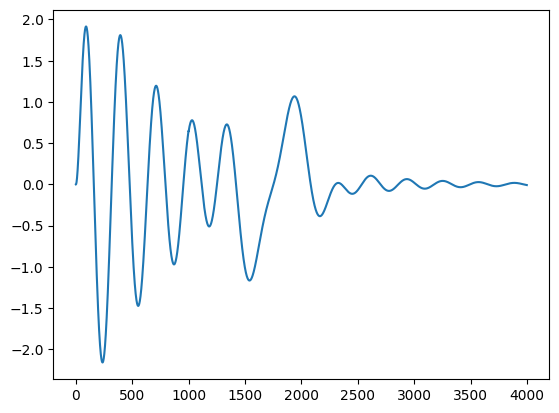

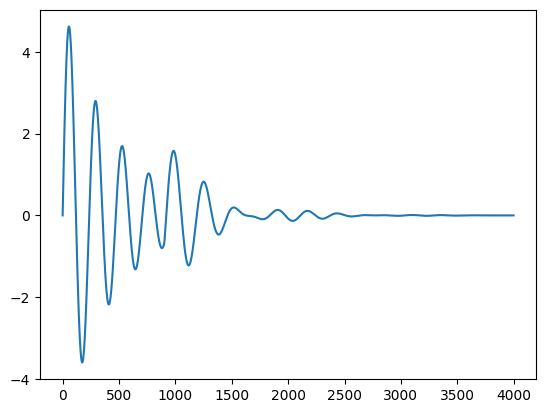

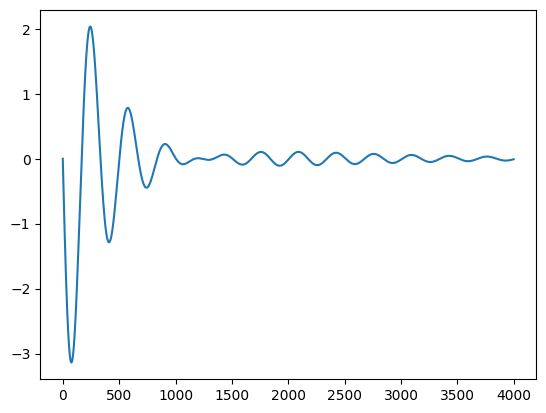

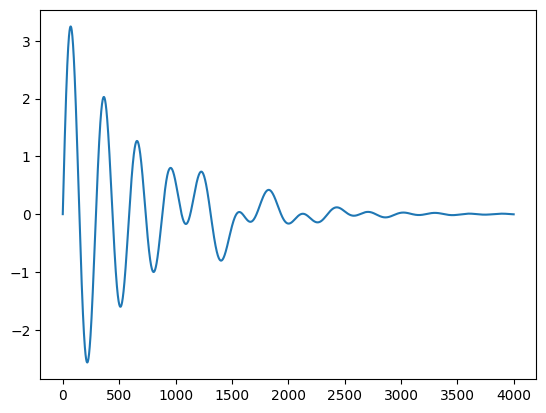

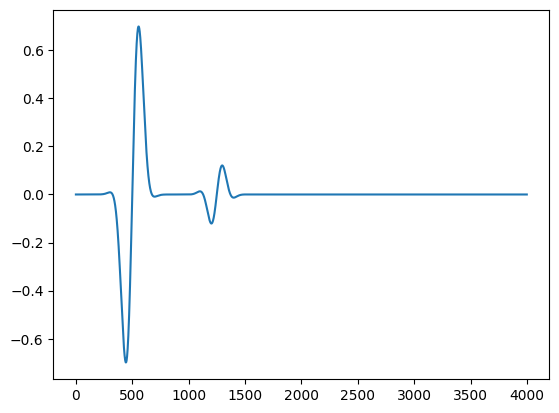

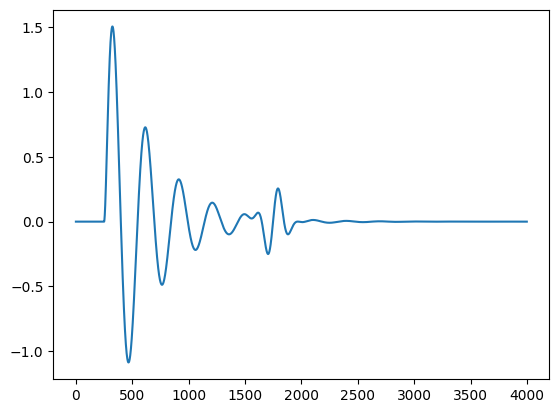

In [2]:
# --- Simulation Parameters ---
# Time settings: 0 to 2 microseconds, with high resolution (1 ns step)
fs = 5e9  # 5 GHz sampling rate
duration = 8e-7 # 100 ns
t_waveform = np.linspace(0, duration, int(duration * fs))

def gr(values, factor=0.4):
    # generate random values
    return (np.random.randn()*values*factor + values)



def simulate_PD1(t):
    return (ws.simulate_DEDO(t, V0=gr(2), alpha=gr(0.1e8), beta=gr(1e8), fc=gr(1e7), theta=0, td=0) + 
            ws.simulate_SMG(t, A=gr(0.7), t0=gr(1.5e-7, 0), tau=gr(0.4e-7), fc=gr(0.5e7), td=gr(2e-7, 0)))

def simulate_PD2(t):
    return (ws.simulate_SEDO(t, V0=gr(3), tau=gr(0.1e-6), fc=gr(2.3e7), theta=0, td=0) + 
            ws.simulate_DEDO(t, V0=gr(0.9), alpha = gr(0.1e8), beta=gr(10e8), fc=gr(1.7e7), theta=0, td=gr(1.8e-7, 0)))

def simulate_PD3(t):
    return ((ws.simulate_SEDO(t, V0=gr(0.5), tau=math.inf, fc=0, theta=np.pi/2, td=0) - 
            ws.simulate_SEDO(t, V0=gr(0.5), tau=gr(0.1e-6), fc=0, theta=np.pi/2, td=0)) *
            ws.simulate_SEDO(t, V0=gr(9), tau=gr(0.15e-6), fc=gr(1.68e7), theta=0, td=0))

def simulate_PD4(t):
    return (ws.simulate_DED(t, V0=gr(3), alpha=gr(0.05e8), beta=gr(0.15e8), td=gr(1.88e-7, 0))*
            ws.simulate_SEDO(t, V0=gr(1.5), tau=gr(0.18e-6), fc=gr(0.9e7), theta=0, td=gr(1.88e-7, 0)) +
            ws.simulate_SEDO(t, V0=gr(3.8), tau = gr(0.12e-6), fc=gr(1.7e7), theta=0, td=0))

def simulate_PD5(t):
    return (ws.simulate_SMG(t, A=gr(1.2), t0=gr(1.0e-7, 0), tau=gr(0.2e-7), fc=gr(2.5e7), td=0) + 
            ws.simulate_SMG(t, A=gr(0.2), t0=gr(2.5e-7, 0), tau=gr(0.2e-7), fc=gr(2.5e7), td=0))

def simulate_PD6(t):
    return (ws.simulate_DEDO(t, V0=gr(2.5), alpha=gr(0.15e8), beta=gr(1.5e8), fc=gr(1.5e7), theta=0, td=gr(0.5e-7, 0)) + 
            ws.simulate_SMG(t, A=gr(0.3), t0=gr(3.5e-7, 0), tau=gr(0.3e-7), fc=gr(3.0e7), td=0))

PD1_waveform = simulate_PD1(t_waveform)
PD2_waveform = simulate_PD2(t_waveform)
PD3_waveform = simulate_PD3(t_waveform)
PD4_waveform = simulate_PD4(t_waveform)
PD5_waveform = simulate_PD5(t_waveform)
PD6_waveform = simulate_PD6(t_waveform)

plt.plot(PD1_waveform)
# plt.savefig('PD1_waveform.png')
plt.show()
plt.plot(PD2_waveform)
# plt.savefig('PD2_waveform.png')
plt.show()
plt.plot(PD3_waveform)
# plt.savefig('PD3_waveform.png')
plt.show()
plt.plot(PD4_waveform)
# plt.savefig('PD4_waveform.png')
plt.show()
plt.plot(PD5_waveform)
# plt.savefig('PD5_waveform.png')
plt.show()
plt.plot(PD6_waveform)
# plt.savefig('PD6_waveform.png')
plt.show()



In [3]:
# Generate signals for each channel

total_time = 4e-4 # 1s
a = 0.2



t = np.arange(0, total_time, 1/fs)
Ch1 = np.zeros(len(t))
Ch2 = np.zeros(len(t))
Ch3 = np.zeros(len(t))
Ch4 = np.zeros(len(t))

Ch1_PD = np.zeros(len(t))
Ch2_PD = np.zeros(len(t))
Ch3_PD = np.zeros(len(t))
Ch4_PD = np.zeros(len(t))

margin = 8e-7

discharge_times_PD1 = np.random.uniform(margin, total_time-margin, 8)
discharge_times_PD2 = np.random.uniform(margin, total_time-margin, 8)
discharge_times_PD3 = np.random.uniform(margin, total_time-margin, 8)
discharge_times_PD4 = np.random.uniform(margin, total_time-margin, 8)
discharge_times_PD5 = np.random.uniform(margin, total_time-margin, 8)
discharge_times_PD6 = np.random.uniform(margin, total_time-margin, 8)


for time in discharge_times_PD1:

    PD1_waveform = simulate_PD1(t_waveform)
    time12 = time + PD1_TDOA12
    time13 = time + PD1_TDOA13
    time14 = time + PD1_TDOA14
    
    Ch1[(t>=time) & (t<=(time+duration))] += PD1_waveform*np.exp(-a*np.linalg.norm(PD1_coords-S1_coords))
    Ch2[(t>=time12) & (t<=(time12+duration))] += PD1_waveform*np.exp(-a*np.linalg.norm(PD1_coords-S2_coords))
    Ch3[(t>=time13) & (t<=(time13+duration))] += PD1_waveform*np.exp(-a*np.linalg.norm(PD1_coords-S3_coords))
    Ch4[(t>=time14) & (t<=(time14+duration))] += PD1_waveform*np.exp(-a*np.linalg.norm(PD1_coords-S4_coords))

    Ch1_PD[(t>=time) & (t<=(time+duration))] = 1
    Ch2_PD[(t>=time12) & (t<=(time12+duration))] = 1
    Ch3_PD[(t>=time13) & (t<=(time13+duration))] = 1
    Ch4_PD[(t>=time14) & (t<=(time14+duration))] = 1

for time in discharge_times_PD2:

    PD2_waveform = simulate_PD2(t_waveform)
    time12 = time + PD2_TDOA12
    time13 = time + PD2_TDOA13
    time14 = time + PD2_TDOA14
    
    Ch1[(t>=time) & (t<=(time+duration))] += PD2_waveform*np.exp(-a*np.linalg.norm(PD2_coords-S1_coords))
    Ch2[(t>=time12) & (t<=(time12+duration))] += PD2_waveform*np.exp(-a*np.linalg.norm(PD2_coords-S2_coords))
    Ch3[(t>=time13) & (t<=(time13+duration))] += PD2_waveform*np.exp(-a*np.linalg.norm(PD2_coords-S3_coords))
    Ch4[(t>=time14) & (t<=(time14+duration))] += PD2_waveform*np.exp(-a*np.linalg.norm(PD2_coords-S4_coords))

    Ch1_PD[(t>=time) & (t<=(time+duration))] = 2
    Ch2_PD[(t>=time12) & (t<=(time12+duration))] = 2
    Ch3_PD[(t>=time13) & (t<=(time13+duration))] = 2
    Ch4_PD[(t>=time14) & (t<=(time14+duration))] = 2
    

for time in discharge_times_PD3:

    PD3_waveform = simulate_PD3(t_waveform)
    time12 = time + PD3_TDOA12
    time13 = time + PD3_TDOA13
    time14 = time + PD3_TDOA14
    
    Ch1[(t>=time) & (t<=(time+duration))] += PD3_waveform*np.exp(-a*np.linalg.norm(PD3_coords-S1_coords))
    Ch2[(t>=time12) & (t<=(time12+duration))] += PD3_waveform*np.exp(-a*np.linalg.norm(PD3_coords-S2_coords))
    Ch3[(t>=time13) & (t<=(time13+duration))] += PD3_waveform*np.exp(-a*np.linalg.norm(PD3_coords-S3_coords))
    Ch4[(t>=time14) & (t<=(time14+duration))] += PD3_waveform*np.exp(-a*np.linalg.norm(PD3_coords-S4_coords))

    Ch1_PD[(t>=time) & (t<=(time+duration))] = 3
    Ch2_PD[(t>=time12) & (t<=(time12+duration))] = 3
    Ch3_PD[(t>=time13) & (t<=(time13+duration))] = 3
    Ch4_PD[(t>=time14) & (t<=(time14+duration))] = 3

for time in discharge_times_PD4:

    PD4_waveform = simulate_PD4(t_waveform)
    time12 = time + PD4_TDOA12
    time13 = time + PD4_TDOA13
    time14 = time + PD4_TDOA14
    
    Ch1[(t>=time) & (t<=(time+duration))] += PD4_waveform*np.exp(-a*np.linalg.norm(PD4_coords-S1_coords))
    Ch2[(t>=time12) & (t<=(time12+duration))] += PD4_waveform*np.exp(-a*np.linalg.norm(PD4_coords-S2_coords))
    Ch3[(t>=time13) & (t<=(time13+duration))] += PD4_waveform*np.exp(-a*np.linalg.norm(PD4_coords-S3_coords))
    Ch4[(t>=time14) & (t<=(time14+duration))] += PD4_waveform*np.exp(-a*np.linalg.norm(PD4_coords-S4_coords))

    Ch1_PD[(t>=time) & (t<=(time+duration))] = 4
    Ch2_PD[(t>=time12) & (t<=(time12+duration))] = 4
    Ch3_PD[(t>=time13) & (t<=(time13+duration))] = 4
    Ch4_PD[(t>=time14) & (t<=(time14+duration))] = 4

for time in discharge_times_PD5:

    PD5_waveform = simulate_PD5(t_waveform)
    time12 = time + PD5_TDOA12
    time13 = time + PD5_TDOA13
    time14 = time + PD5_TDOA14

    Ch1[(t>=time) & (t<=(time+duration))] += PD5_waveform*np.exp(-a*np.linalg.norm(PD5_coords-S1_coords))
    Ch2[(t>=time12) & (t<=(time12+duration))] += PD5_waveform*np.exp(-a*np.linalg.norm(PD5_coords-S2_coords))
    Ch3[(t>=time13) & (t<=(time13+duration))] += PD5_waveform*np.exp(-a*np.linalg.norm(PD5_coords-S3_coords))
    Ch4[(t>=time14) & (t<=(time14+duration))] += PD5_waveform*np.exp(-a*np.linalg.norm(PD5_coords-S4_coords))

    Ch1_PD[(t>=time) & (t<=(time+duration))] = 5
    Ch2_PD[(t>=time12) & (t<=(time12+duration))] = 5
    Ch3_PD[(t>=time13) & (t<=(time13+duration))] = 5
    Ch4_PD[(t>=time14) & (t<=(time14+duration))] = 5

for time in discharge_times_PD6:

    PD6_waveform = simulate_PD6(t_waveform)
    time12 = time + PD6_TDOA12
    time13 = time + PD6_TDOA13
    time14 = time + PD6_TDOA14

    Ch1[(t>=time) & (t<=(time+duration))] += PD6_waveform*np.exp(-a*np.linalg.norm(PD6_coords-S1_coords))
    Ch2[(t>=time12) & (t<=(time12+duration))] += PD6_waveform*np.exp(-a*np.linalg.norm(PD6_coords-S2_coords))
    Ch3[(t>=time13) & (t<=(time13+duration))] += PD6_waveform*np.exp(-a*np.linalg.norm(PD6_coords-S3_coords))
    Ch4[(t>=time14) & (t<=(time14+duration))] += PD6_waveform*np.exp(-a*np.linalg.norm(PD6_coords-S4_coords))

    Ch1_PD[(t>=time) & (t<=(time+duration))] = 6
    Ch2_PD[(t>=time12) & (t<=(time12+duration))] = 6
    Ch3_PD[(t>=time13) & (t<=(time13+duration))] = 6
    Ch4_PD[(t>=time14) & (t<=(time14+duration))] = 6

    



In [4]:
'''
# Gemini code
# 1. Define your sensor coordinates in a list for easy iteration
sensor_coords = [S1_coords, S2_coords, S3_coords, S4_coords]
channels = [Ch1, Ch2, Ch3, Ch4]

# 2. Group the PD source data into a list of dictionaries
pd_sources = [
    {'times': discharge_times_PD1, 'func': simulate_PD1, 'coords': PD1_coords, 'tdoas': [0, PD1_TDOA12, PD1_TDOA13, PD1_TDOA14]},
    {'times': discharge_times_PD2, 'func': simulate_PD2, 'coords': PD2_coords, 'tdoas': [0, PD2_TDOA12, PD2_TDOA13, PD2_TDOA14]},
    {'times': discharge_times_PD3, 'func': simulate_PD3, 'coords': PD3_coords, 'tdoas': [0, PD3_TDOA12, PD3_TDOA13, PD3_TDOA14]},
    {'times': discharge_times_PD4, 'func': simulate_PD4, 'coords': PD4_coords, 'tdoas': [0, PD4_TDOA12, PD4_TDOA13, PD4_TDOA14]},
    {'times': discharge_times_PD5, 'func': simulate_PD5, 'coords': PD5_coords, 'tdoas': [0, PD5_TDOA12, PD5_TDOA13, PD5_TDOA14]},
    {'times': discharge_times_PD6, 'func': simulate_PD6, 'coords': PD6_coords, 'tdoas': [0, PD6_TDOA12, PD6_TDOA13, PD6_TDOA14]},
]

# 3. Process all PD sources in a single nested loop
for source in pd_sources:
    # Pre-calculate attenuation for each channel for this specific source
    attenuations = [np.exp(-a * np.linalg.norm(source['coords'] - s_coord)) for s_coord in sensor_coords]
    
    for start_time in source['times']:
        # Simulate the pulse waveform once per discharge
        waveform = source['func']()
        
        for i in range(4):
            arrival_time = start_time + source['tdoas'][i]
            # Use boolean indexing to add the shifted and attenuated waveform
            mask = (t >= arrival_time) & (t <= (arrival_time + duration))
            
            # Note: Ensure that the waveform length matches the mask length 
            # or use a fixed number of samples to avoid broadcasting errors
            channels[i][mask] += waveform[:np.sum(mask)] * attenuations[i]
'''

"\n# Gemini code\n# 1. Define your sensor coordinates in a list for easy iteration\nsensor_coords = [S1_coords, S2_coords, S3_coords, S4_coords]\nchannels = [Ch1, Ch2, Ch3, Ch4]\n\n# 2. Group the PD source data into a list of dictionaries\npd_sources = [\n    {'times': discharge_times_PD1, 'func': simulate_PD1, 'coords': PD1_coords, 'tdoas': [0, PD1_TDOA12, PD1_TDOA13, PD1_TDOA14]},\n    {'times': discharge_times_PD2, 'func': simulate_PD2, 'coords': PD2_coords, 'tdoas': [0, PD2_TDOA12, PD2_TDOA13, PD2_TDOA14]},\n    {'times': discharge_times_PD3, 'func': simulate_PD3, 'coords': PD3_coords, 'tdoas': [0, PD3_TDOA12, PD3_TDOA13, PD3_TDOA14]},\n    {'times': discharge_times_PD4, 'func': simulate_PD4, 'coords': PD4_coords, 'tdoas': [0, PD4_TDOA12, PD4_TDOA13, PD4_TDOA14]},\n    {'times': discharge_times_PD5, 'func': simulate_PD5, 'coords': PD5_coords, 'tdoas': [0, PD5_TDOA12, PD5_TDOA13, PD5_TDOA14]},\n    {'times': discharge_times_PD6, 'func': simulate_PD6, 'coords': PD6_coords, 'tdoas': [

In [5]:
def add_gaussian_noise(signal, snr_db):
    """Adds noise to a signal based on a target SNR in decibels."""
    sig_power = np.mean(signal**2)
    sig_avg_db = 10 * np.log10(sig_power)
    noise_avg_db = sig_avg_db - snr_db
    noise_avg_watts = 10 ** (noise_avg_db / 10)
    
    noise = np.random.normal(0, np.sqrt(noise_avg_watts), len(signal))
    return signal + noise

Ch1 = add_gaussian_noise(Ch1, 20)
Ch2 = add_gaussian_noise(Ch2, 20)
Ch3 = add_gaussian_noise(Ch3, 20)
Ch4 = add_gaussian_noise(Ch4, 20)

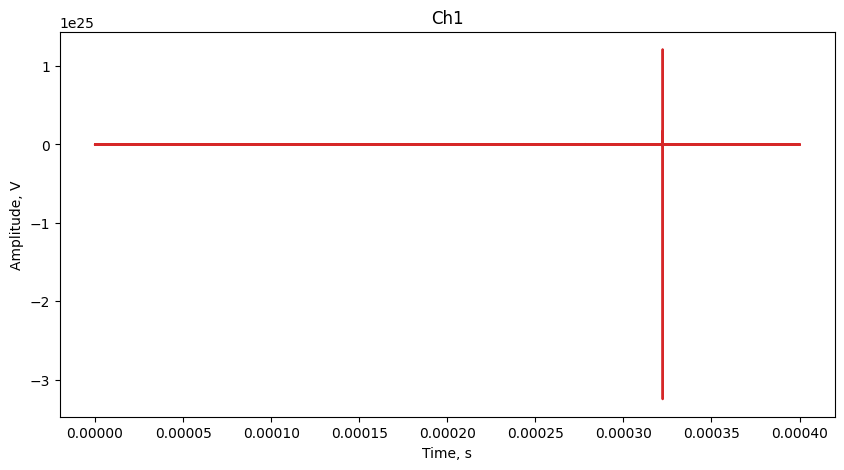

In [6]:
fig = plt.figure(figsize=(10,5))
plt.plot(t, Ch1, label = "Ch1", color = "tab:red")
plt.title("Ch1")
plt.xlabel("Time, s")
plt.ylabel("Amplitude, V")
plt.show()

In [7]:
import os

# 1. Create the directory if it doesn't already exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. Save each channel to a separate CSV file
# We stack 't' and the channel data so that Column 0 = Time, Column 1 = Voltage
np.savetxt(os.path.join(OUTPUT_DIR, "Ch1.csv"), np.column_stack((t, Ch1, Ch1_PD)), delimiter=",")
np.savetxt(os.path.join(OUTPUT_DIR, "Ch2.csv"), np.column_stack((t, Ch2, Ch2_PD)), delimiter=",")
np.savetxt(os.path.join(OUTPUT_DIR, "Ch3.csv"), np.column_stack((t, Ch3, Ch3_PD)), delimiter=",")
np.savetxt(os.path.join(OUTPUT_DIR, "Ch4.csv"), np.column_stack((t, Ch4, Ch4_PD)), delimiter=",")

print(f"Successfully saved Ch1 to Ch4 in the '{OUTPUT_DIR}' directory.")

Successfully saved Ch1 to Ch4 in the 'Simulated_Waveforms' directory.


In [8]:
'''
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Group the coordinates for plotting
pd_list = np.array([PD1_coords, PD2_coords, PD3_coords, PD4_coords, PD5_coords, PD6_coords])
s_list = np.array([S1_coords, S2_coords, S3_coords, S4_coords])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot PD Sensors (Blue Circles)
ax.scatter(pd_list[:, 0], pd_list[:, 1], pd_list[:, 2], 
           c='blue', marker='o', s=100, label='PD Sensors')

# Add labels for PD sensors
for i, coord in enumerate(pd_list):
    ax.text(coord[0], coord[1], coord[2], f'PD{i+1}', size=10, zorder=1, color='black')

# Plot Sources (Red Triangles)
ax.scatter(s_list[:, 0], s_list[:, 1], s_list[:, 2], 
           c='red', marker='^', s=100, label='Sources')

# Add labels for Sources
for i, coord in enumerate(s_list):
    ax.text(coord[0], coord[1], coord[2], f'S{i+1}', size=10, zorder=1, color='darkred')

# Set labels and title
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('3D Layout of Sensors and Sources')
ax.legend()

plt.show()
plt.savefig('3D_Layout.png')
'''

"\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\n\n# Group the coordinates for plotting\npd_list = np.array([PD1_coords, PD2_coords, PD3_coords, PD4_coords, PD5_coords, PD6_coords])\ns_list = np.array([S1_coords, S2_coords, S3_coords, S4_coords])\n\nfig = plt.figure(figsize=(10, 7))\nax = fig.add_subplot(111, projection='3d')\n\n# Plot PD Sensors (Blue Circles)\nax.scatter(pd_list[:, 0], pd_list[:, 1], pd_list[:, 2], \n           c='blue', marker='o', s=100, label='PD Sensors')\n\n# Add labels for PD sensors\nfor i, coord in enumerate(pd_list):\n    ax.text(coord[0], coord[1], coord[2], f'PD{i+1}', size=10, zorder=1, color='black')\n\n# Plot Sources (Red Triangles)\nax.scatter(s_list[:, 0], s_list[:, 1], s_list[:, 2], \n           c='red', marker='^', s=100, label='Sources')\n\n# Add labels for Sources\nfor i, coord in enumerate(s_list):\n    ax.text(coord[0], coord[1], coord[2], f'S{i+1}', size=10, zorder=1, color='darkred')\n\n# Set labels and title\nax.se

In [9]:
'''
import scipy.stats as stats
x = np.linspace(-0.15, 0.15, 500)
# Calculate the Kernel Density Estimate (KDE) of the amplitude distribution
kde = stats.gaussian_kde(Ch1)
y = kde(x)
idx = np.where(y>=(np.max(y)*0.01))
idx = [idx[0][0], idx[0][-1]]

idx_max = np.where(y==(np.max(y)))
fig, ax = plt.subplots()
ax.plot(x, y)
ax.scatter(x[idx], y[idx], color='red', label='0.01*max_density', s=100)
ax.text(x[idx[0]]-0.07, y[idx[0]], f'({x[idx[0]]:.2f}, {y[idx[0]]:.2f})', fontsize=12, verticalalignment='bottom')
ax.text(x[idx[-1]], y[idx[-1]], f'({x[idx[-1]]:.2f}, {y[idx[-1]]:.2f})', fontsize=12, verticalalignment='bottom')
ax.set_title("Kernel Density Estimate (Simulated Sensor Data)")
ax.set_xlabel("Amplitude of sensor reading, V")
ax.set_ylabel(r"Density, V$^{-1}$")
ax.legend()
plt.show()
'''

'\nimport scipy.stats as stats\nx = np.linspace(-0.15, 0.15, 500)\n# Calculate the Kernel Density Estimate (KDE) of the amplitude distribution\nkde = stats.gaussian_kde(Ch1)\ny = kde(x)\nidx = np.where(y>=(np.max(y)*0.01))\nidx = [idx[0][0], idx[0][-1]]\n\nidx_max = np.where(y==(np.max(y)))\nfig, ax = plt.subplots()\nax.plot(x, y)\nax.scatter(x[idx], y[idx], color=\'red\', label=\'0.01*max_density\', s=100)\nax.text(x[idx[0]]-0.07, y[idx[0]], f\'({x[idx[0]]:.2f}, {y[idx[0]]:.2f})\', fontsize=12, verticalalignment=\'bottom\')\nax.text(x[idx[-1]], y[idx[-1]], f\'({x[idx[-1]]:.2f}, {y[idx[-1]]:.2f})\', fontsize=12, verticalalignment=\'bottom\')\nax.set_title("Kernel Density Estimate (Simulated Sensor Data)")\nax.set_xlabel("Amplitude of sensor reading, V")\nax.set_ylabel(r"Density, V$^{-1}$")\nax.legend()\nplt.show()\n'

In [10]:
i=0
for element in discharge_times_PD1:
    idx = np.where(t>=element)[0][0]
    print(f"PD1_{i} discharge index: {idx}, discharge time: {element}")
    i+=1

i=0
for element in discharge_times_PD2:
    idx = np.where(t>=element)[0][0]
    print(f"PD2_{i} discharge index: {idx}, discharge time: {element}")
    i+=1

i=0
for element in discharge_times_PD3:
    idx = np.where(t>=element)[0][0]
    print(f"PD3_{i} discharge index: {idx}, discharge time: {element}")
    i+=1

i=0
for element in discharge_times_PD4:
    idx = np.where(t>=element)[0][0]
    print(f"PD4_{i} discharge index: {idx}, discharge time: {element}")
    i+=1

i=0
for element in discharge_times_PD5:
    idx = np.where(t>=element)[0][0]
    print(f"PD5_{i} discharge index: {idx}, discharge time: {element}")
    i+=1

i=0
for element in discharge_times_PD6:
    idx = np.where(t>=element)[0][0]
    print(f"PD6_{i} discharge index: {idx}, discharge time: {element}")
    i+=1


PD1_0 discharge index: 1881380, discharge time: 0.00037627584948995594
PD1_1 discharge index: 1726762, discharge time: 0.0003453522871438163
PD1_2 discharge index: 389699, discharge time: 7.793968483358844e-05
PD1_3 discharge index: 230370, discharge time: 4.6073961023892034e-05
PD1_4 discharge index: 601830, discharge time: 0.00012036586473498352
PD1_5 discharge index: 1186340, discharge time: 0.00023726788863586128
PD1_6 discharge index: 775362, discharge time: 0.00015507239810016283
PD1_7 discharge index: 1076649, discharge time: 0.00021532961381505388
PD2_0 discharge index: 1245181, discharge time: 0.00024903606871700394
PD2_1 discharge index: 1298504, discharge time: 0.0002597006308953189
PD2_2 discharge index: 1447962, discharge time: 0.00028959226174741544
PD2_3 discharge index: 1352965, discharge time: 0.0002705929849957732
PD2_4 discharge index: 1849739, discharge time: 0.00036994760591422355
PD2_5 discharge index: 1224655, discharge time: 0.00024493091982017817
PD2_6 discharg

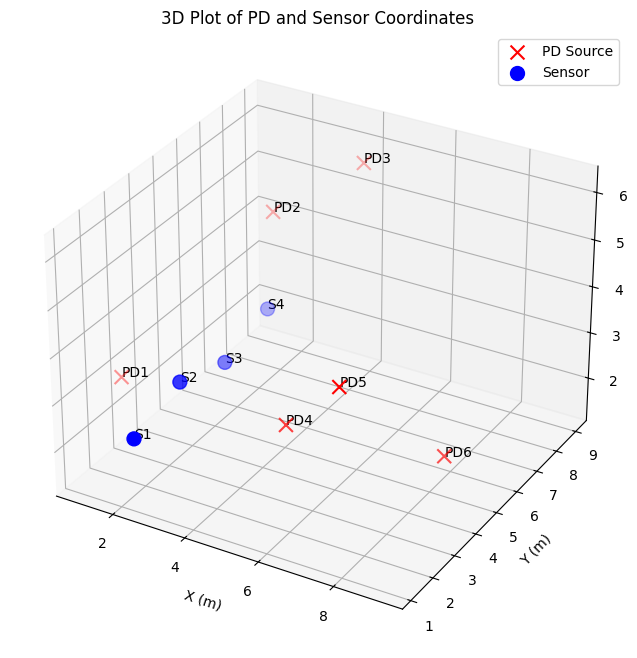

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define Coordinates ---

# Partial Discharge (PD) Coordinates
# format: [x, y, z]
pd_coords = np.array([
    [1.2, 2.3, 3.1], # PD1
    [2.9, 6.3, 5.4], # PD2
    [4.5, 7.8, 6.2], # PD3
    [6.1, 1.7, 3.5], # PD4
    [7.8, 1.2, 4.9], # PD5
    [9.2, 3.5, 2.8]  # PD6
])

# Sensor Coordinates
sensor_coords = np.array([
    [1.0, 3.0, 1.4], # S1
    [1.0, 5.0, 1.8], # S2
    [1.0, 7.0, 1.4], # S3
    [1.0, 9.0, 1.8]  # S4
])

# --- Plotting ---

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot PDs
ax.scatter(pd_coords[:, 0], pd_coords[:, 1], pd_coords[:, 2], 
           c='red', marker='x', s=100, label='PD Source')

# Plot Sensors
ax.scatter(sensor_coords[:, 0], sensor_coords[:, 1], sensor_coords[:, 2], 
           c='blue', marker='o', s=100, label='Sensor')

# Add labels for PDs
for i, (x, y, z) in enumerate(pd_coords):
    ax.text(x, y, z, f'PD{i+1}', size=10, zorder=1, color='k') 

# Add labels for Sensors
for i, (x, y, z) in enumerate(sensor_coords):
    ax.text(x, y, z, f'S{i+1}', size=10, zorder=1, color='k')

# Set labels and title
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Plot of PD and Sensor Coordinates')
ax.legend()

plt.show()